<a href="https://colab.research.google.com/github/Ayu-sshhhhh/Food-Vision-Classifier/blob/main/Transfer_Learning_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here we will conduct a series of experiments with different models trained for our main Food Vision Classifier model.

1. `model_1` - use featue extraction transfer learning with 1 % of the training data with data augmentation.
2. `model_2` - use feature extraction transfer learning with 10 % of the training with data augmentation.
3. `model_3` - use fine-tuning transfer learning on 10 % of the training data with data augmentation.
4. `model_4` - use fine-tuning transfer learning on 100 % of the training data with data augmentation.

> **Note:** throughtout all experiments the same tets dataset will be uesd to evaluate our model...this ensures consistency across evaluation matrices.

## Getting and preprocessing data for model_1

In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-05-21 13:27:59--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0.001s  

2026-05-21 13:28:00 (19.3 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [2]:
from helper_functions import unzip_data

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip

unzip_data("10_food_classes_1_percent.zip")

--2026-05-21 13:28:08--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.135.207, 173.194.43.207, 74.125.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.135.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M   105MB/s    in 1.2s    

2026-05-21 13:28:09 (105 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]



In [3]:
train_dir_1_percent = "10_food_classes_1_percent/train"
test_dir = "10_food_classes_1_percent/test"

In [4]:
from helper_functions import walk_through_dir
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/test'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/fried_rice'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/steak'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/grilled_salmon'

In [5]:
import tensorflow as tf
IMG_SIZE = (224,224)
BATCH_SIZE = 32
train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir_1_percent,
                                                                      image_size=IMG_SIZE,
                                                                      label_mode="categorical",
                                                                      batch_size=BATCH_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size = IMG_SIZE,
                                                                batch_size = BATCH_SIZE)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


## Adding data augmentation into our model

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    # layers.Rescale(1./255)
], name = "data_augmentation")

## Visualize our data augmentation layer

10_food_classes_1_percent/train/pizza


Text(0.5, 1.0, 'Augmented random image from class: pizza')

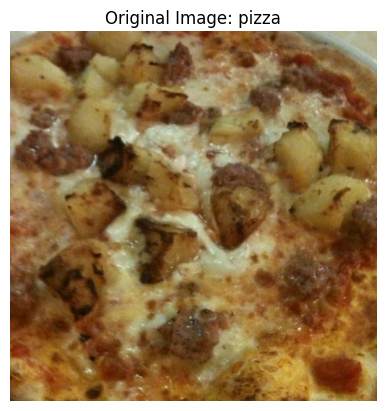

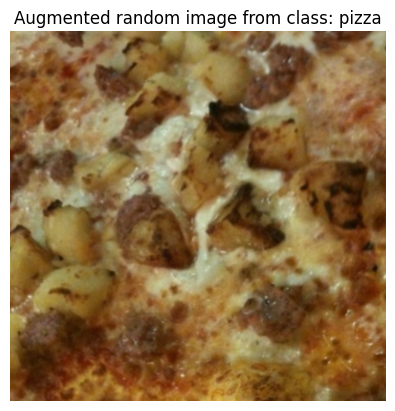

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
target_class = random.choice(train_data_1_percent.class_names)
target_dir = "10_food_classes_1_percent/train/" + target_class
random_image = random.choice(os.listdir(target_dir))
random_image_path = target_dir + "/" + random_image
print(target_dir)
img = mpimg.imread(random_image_path)
plt.title(f"Original Image: {target_class}")
plt.axis(False);
plt.imshow(img)
# Plotting our augmented image
augmented_image = data_augmentation(tf.expand_dims(img, axis=0))
plt.figure()
plt.axis(False);
plt.imshow(tf.squeeze(augmented_image)/255.)
plt.title(f"Augmented random image from class: {target_class}")

Our baseline model was trained on 10 % of our dataset

# Model 1 : Feature extraction transfer learning on 1 % of the data with data augmentation

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from helper_functions import create_tensorboard_callback
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
], name = "data_augmentation")

input_shape = (224,224,3)
base_model = tf.keras.applications.EfficientNetV2B0(include_top=False)
base_model.trainable = False
inputs = layers.Input(shape=input_shape, name="input_layer")
x = data_augmentation(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(10, activation="softmax", name = "output_layer")(x)
model_1 = keras.Model(inputs, outputs, name = "model_1")
model_1.compile(loss="categorical_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
history_1_percent = model_1.fit(train_data_1_percent,
                               epochs=5,
                               steps_per_epoch = len(train_data_1_percent),
                               validation_data = test_data,
                               validation_steps = int(len(test_data)),
                               callbacks = [create_tensorboard_callback(dir_name="transfer_learning",
                                                                       experiment_name = "1_percent_data_aug")])

Saving TensorBoard log files to: transfer_learning/1_percent_data_aug/20260521-132822
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 7s/step - accuracy: 0.1286 - loss: 2.3347 - val_accuracy: 0.2184 - val_loss: 2.1635
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.2429 - loss: 2.1440 - val_accuracy: 0.3096 - val_loss: 2.0594
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.3714 - loss: 1.9995 - val_accuracy: 0.3752 - val_loss: 1.9695
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step - accuracy: 0.4143 - loss: 1.8875 - val_accuracy: 0.4384 - val_loss: 1.8885
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.4857 - loss: 1.8098 - val_accuracy: 0.4820 - val_loss: 1.8135


In [10]:
IMG_SIZE + (3,)

(224, 224, 3)

In [11]:
# Checking our model_1 summary
model_1.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,957,744 (22.73 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 25,622 (100.09 KB)

In [12]:
results_1_percent = model_1.evaluate(test_data)
results_1_percent[1]

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.4820 - loss: 1.8135


0.4819999933242798

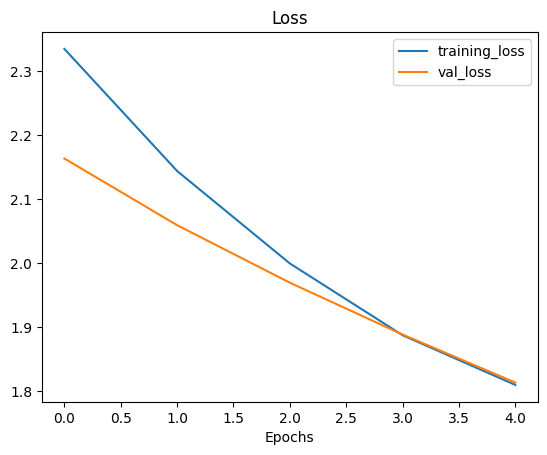

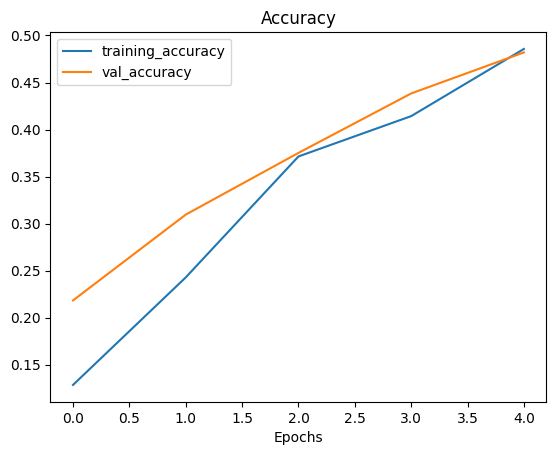

In [13]:
from helper_functions import plot_loss_curves
plot_loss_curves(history_1_percent)

# Model 2 : traing our model on 10 % of dataset

In [14]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
unzip_data("10_food_classes_10_percent.zip")

--2026-05-21 13:29:47--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.163.207, 74.125.20.207, 108.177.98.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   197MB/s    in 0.8s    

2026-05-21 13:29:48 (197 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [15]:
train_dir_10_percent = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

In [16]:
import tensorflow as tf
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir_10_percent,
                                                                      image_size=IMG_SIZE,
                                                                      label_mode="categorical",
                                                                      batch_size=BATCH_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size = IMG_SIZE,
                                                                batch_size = BATCH_SIZE)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [17]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2)], name="data_augmentation")

In [18]:
input_shape = (224,224,3)

base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=input_shape, name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_2D")(x)
outputs = layers.Dense(10, activation="softmax", name = "output_layer")(x)
model_2 = keras.Model(inputs, outputs, name="output_layer")
model_2.compile(loss="categorical_crossentropy",
                optimizer = "Adam",
                metrics=["accuracy"])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [19]:
model_2.summary()

Model: "output_layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_2D       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Creating a model checkpoint callback

In [20]:
checkpoint_path = "ten_percent_model_checkpoints__weights/checkpoint.weights.h5"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only = True,
                                                         save_best_only=False,
                                                         save_freq= "epoch",
                                                         verbose=1)

## Fit model 2 passing in the ModelCheckpoint callback

In [21]:
initial_epochs = 5
history_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                 epochs=initial_epochs,
                                 steps_per_epoch = len(train_data_10_percent),
                                 validation_data = test_data,
                                 validation_steps = int(0.25*len(test_data)),
                                 callbacks = [create_tensorboard_callback(dir_name="transfer_learning", experiment_name="10_percent_data_aug"),
                                              checkpoint_callback])

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug/20260521-132953
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.2866 - loss: 2.1358
Epoch 1: saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5

Epoch 1: finished saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 328ms/step - accuracy: 0.3920 - loss: 1.9367 - val_accuracy: 0.7023 - val_loss: 1.3788
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7075 - loss: 1.3753
Epoch 2: saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5

Epoch 2: finished saving model to ten_percent_model_checkpoints__weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.7213 - loss: 1.2928 - val_accuracy: 0.7928 - val_loss: 0.9816
Epoch 3/5
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7734 - loss: 1.0420
Epoch 3: saving model to ten_percent_model_checkpoints__wei

In [22]:
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.4820 - loss: 1.8135


[1.813510537147522, 0.4819999933242798]

In [23]:
results_10_percent_data_aug = model_2.evaluate(test_data)
results_10_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.8396 - loss: 0.6315


[0.6314763426780701, 0.8396000266075134]

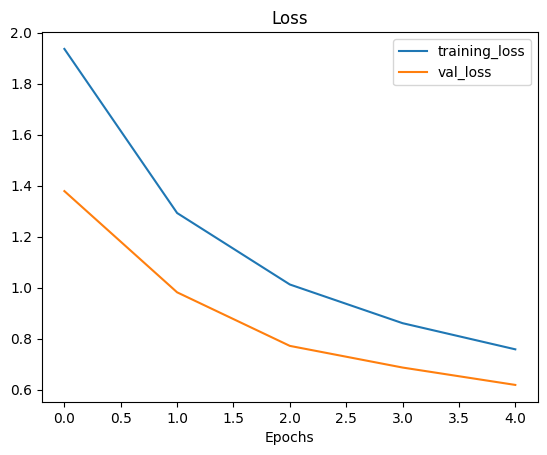

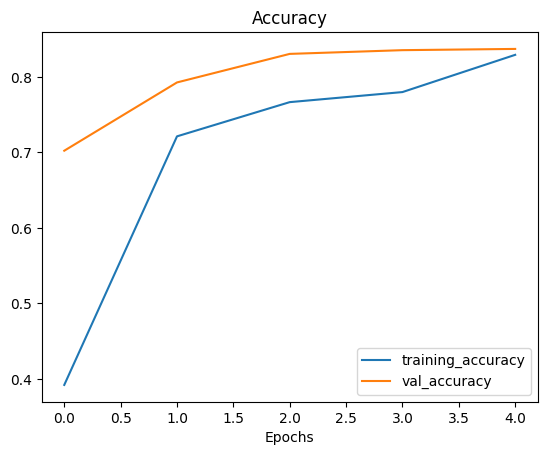

In [24]:
plot_loss_curves(history_10_percent_data_aug)

In [25]:
model_2.load_weights(checkpoint_path)

In [26]:
# Evaluate our model_2 with loaded weights
loaded_weights_model_results = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8396 - loss: 0.6315


In [27]:
results_10_percent_data_aug

[0.6314763426780701, 0.8396000266075134]

In [28]:
loaded_weights_model_results

[0.6314763426780701, 0.8396000266075134]

In [29]:
import numpy as np
np.isclose(np.array(results_10_percent_data_aug), np.array(loaded_weights_model_results))

array([ True,  True])

# Model 3 : fin-tuning an existing model for 10% of data

In [30]:
model_2.layers

[<InputLayer name=input_layer, built=True>,
 <Sequential name=data_augmentation, built=True>,
 <Functional name=efficientnetb0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling_2D, built=True>,
 <Dense name=output_layer, built=True>]

In [31]:
for layer in model_2.layers:
  print(layers, layer.trainable)

<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> False
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True
<module 'keras._tf_keras.keras.layers' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/layers/__init__.py'> True


In [35]:
for i, layer in enumerate(model_2.layers[2].layers):
  print(i, layer.name, layer.trainable)

0 input_layer_3 False
1 rescaling_1 False
2 normalization_1 False
3 rescaling_2 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [37]:
print(len(model_2.layers[2].trainable_variables))

0


In [40]:
# We will set the last ten layers of our base model.trainable = True
base_model.trainable = True

for layer in base_model.layers[:-10]:
  layer.trainable = False

# Recompiling every time we make a change
model_2.compile(loss="categorical_crossentropy",
                optimizer = "Adam",
                metrics=["accuracy"])